# Inspect ESP Projection .pt Files

Set `data_dir` or `pt_path` below, then run the cells to load and visualize projections and rotations.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import torch

In [2]:
# Set either data_dir (directory with .pt files) or pt_path (specific .pt file).
data_dir = Path("../../../../pipeline_inputs/projections/7T54")
pt_path = None  # Path("/path/to/7t54_esp_projections_10.pt")

if pt_path is None:
    if not data_dir.exists():
        raise FileNotFoundError(f"data_dir not found: {data_dir.resolve()}")
    pt_files = sorted(data_dir.glob("*.pt"))
    if not pt_files:
        raise FileNotFoundError(f"No .pt files found in {data_dir.resolve()}")
    pt_path = pt_files[0]

pt_path = Path(pt_path)
print(f"Loading: {pt_path}")

Loading: ../../../../pipeline_inputs/projections/7T54/7T54_FIXED_esp_projections_200.pt


In [3]:
data = torch.load(pt_path, map_location="cpu", weights_only=False)
print("Keys:", list(data.keys()))

projections = data["projections"]
rotations = data["rotations"]
meta = data.get("meta")

print("projections shape:", tuple(projections.shape))
print("rotations shape:", tuple(rotations.shape))
if meta is not None:
    print("meta:")
    print(json.dumps(meta, indent=2))
else:
    json_path = pt_path.with_suffix(".json")
    if json_path.exists():
        print("meta (from json):")
        print(json_path.read_text())

Keys: ['projections', 'rotations', 'meta']
projections shape: (200, 300, 300)
rotations shape: (200, 3, 3)
meta:
{
  "pdb_id": "7T54_FIXED",
  "pdb_path": "pipeline_inputs/pdbs/7T54/7t54_fixed.pdb",
  "density_map": "pipeline_inputs/pdbs/7T54/emd_25694.map",
  "num_rotations": 200,
  "projection_axis": "z",
  "bfactor_override": null,
  "atomic_radius": 0.5,
  "device": "cuda",
  "lattice": {
    "grid_dimensions": [
      300,
      300,
      1
    ],
    "voxel_sizes": [
      1.03,
      1.03,
      309.0
    ],
    "left_bottom": [
      -3.0900000000000003e-07,
      -3.0900000000000003e-07,
      153.985
    ],
    "right_upper": [
      307.970000309,
      307.970000309,
      153.985
    ],
    "D": 300,
    "pixel_size": 1.03,
    "sublattice_radius": 14.0,
    "projection_axis": 2,
    "projection_depth": 309.0,
    "collapse_projection_axis": true
  },
  "resolved_atoms_only": true,
  "resolved_atoms": 2376,
  "total_atoms": 2377
}


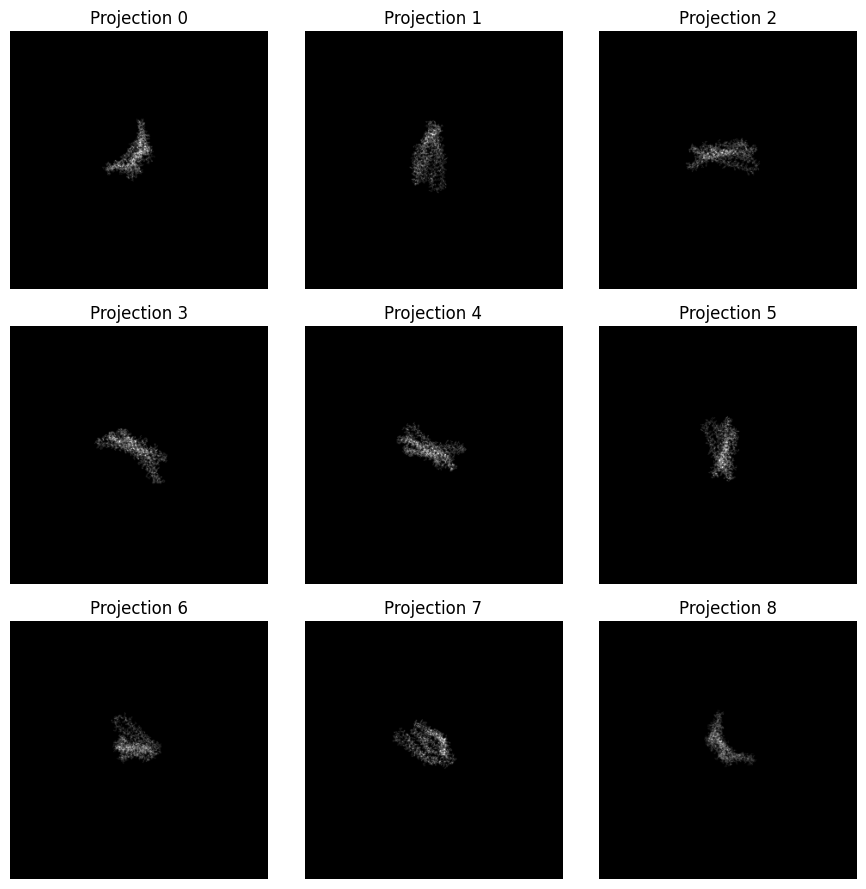

In [4]:
# Visualize a 3x3 grid of projections
num = min(9, projections.shape[0])
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num:
        ax.imshow(projections[i].numpy(), cmap="gray", origin="lower")
        ax.set_title(f"Projection {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [5]:
# Inspect a rotation matrix
idx = 0
rot = rotations[idx]
print(rot)
print("determinant:", torch.det(rot).item())
print("orthonormal check (R^T R):")
print((rot.T @ rot).numpy())

tensor([[-0.8224, -0.0044, -0.5688],
        [ 0.1291, -0.9753, -0.1792],
        [-0.5540, -0.2208,  0.8027]])
determinant: 1.000000238418579
orthonormal check (R^T R):
[[1.0000002e+00 6.3346706e-09 3.2182612e-08]
 [6.3346706e-09 1.0000002e+00 9.5038857e-09]
 [3.2182612e-08 9.5038857e-09 1.0000001e+00]]


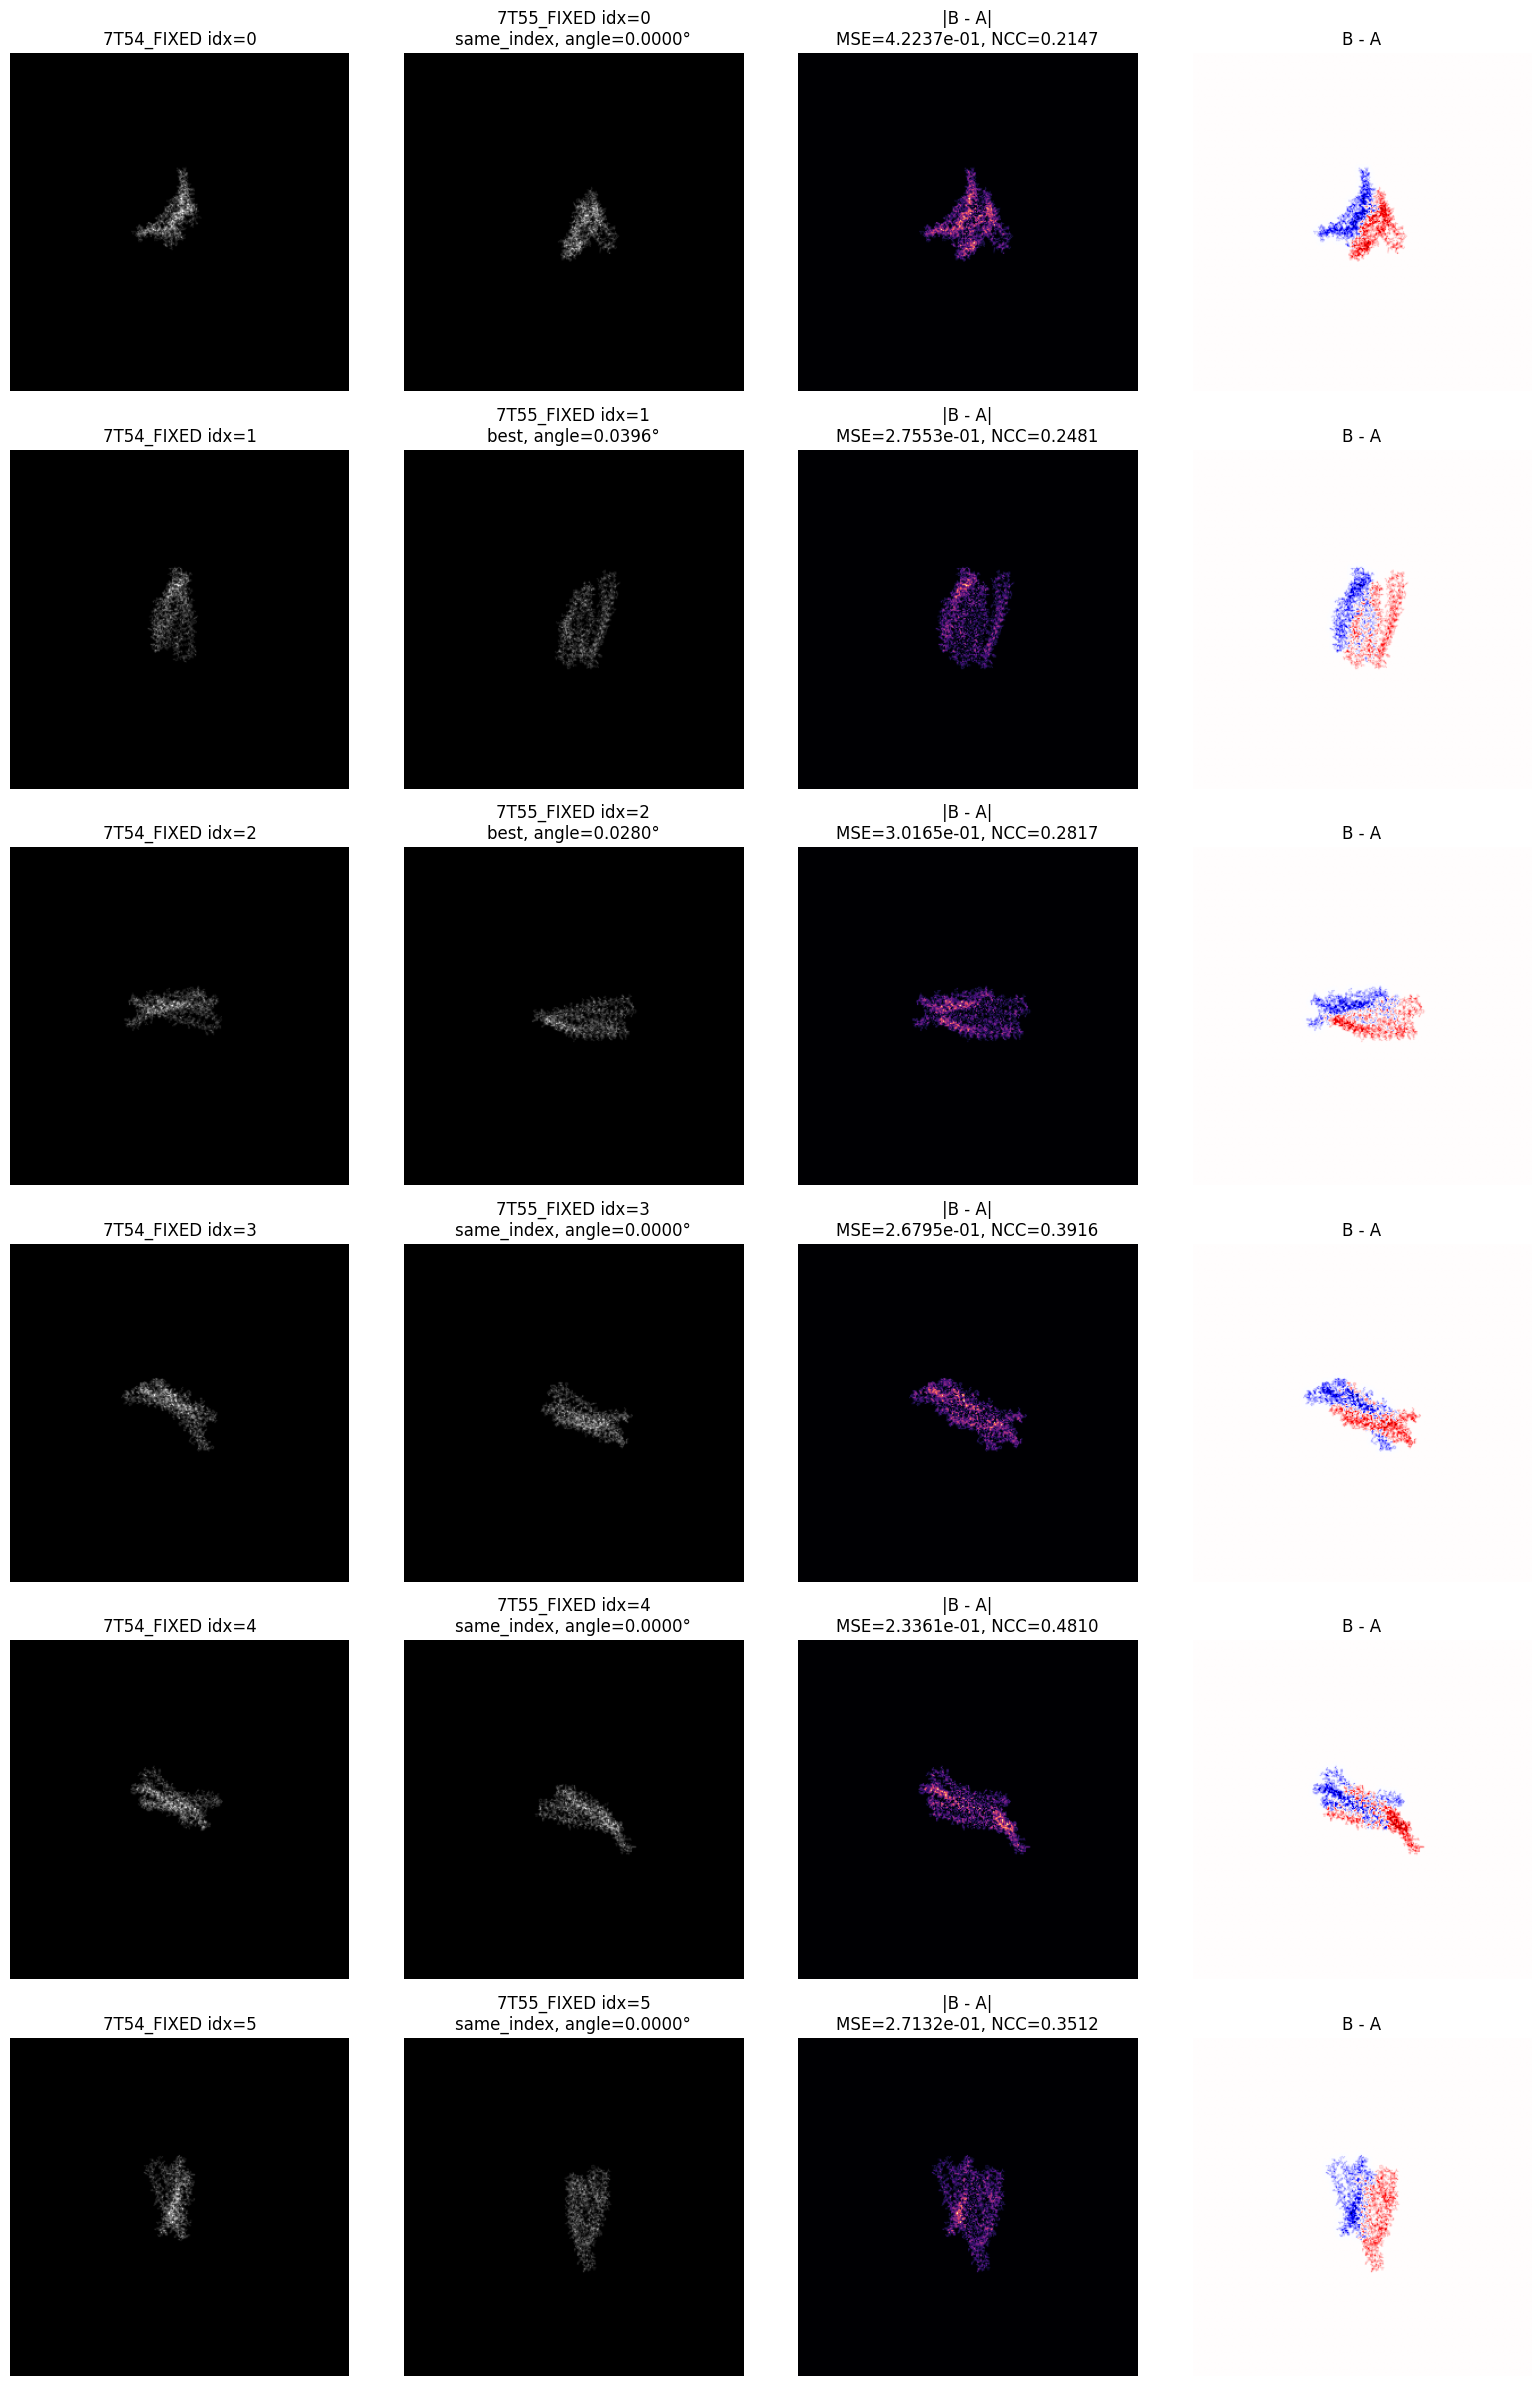

Dataset A: ../../../../pipeline_inputs/projections/7T54/7T54_FIXED_esp_projections_200.pt
Dataset B: ../../../../pipeline_inputs/projections/7T55-unaligned/7T55_FIXED_esp_projections_200.pt
A[0] -> B[0] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=4.223692e-01, NCC=0.214658
A[1] -> B[1] (best), angle=0.039565°, same-index angle=0.039565°, best angle=0.039565°, MSE=2.755274e-01, NCC=0.248090
A[2] -> B[2] (best), angle=0.027976°, same-index angle=0.027976°, best angle=0.027976°, MSE=3.016486e-01, NCC=0.281718
A[3] -> B[3] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=2.679465e-01, NCC=0.391570
A[4] -> B[4] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=2.336059e-01, NCC=0.481042
A[5] -> B[5] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=2.713190e-01, NCC=0.351243


In [6]:
# Compare two datasets at the same rotation index when possible, otherwise use the nearest rotation.
compare_pt_path_a = pt_path
compare_data_dir_b = Path("../../../../pipeline_inputs/projections/7T55-unaligned")
compare_pt_path_b = None  # Path("/path/to/7T55_esp_projections_200.pt")
compare_indices_a = None  # e.g. [0, 10, 42]
num_examples = 6
match_mode = "same_index_if_close_else_best"  # "same_index", "best"
same_index_angle_tol_deg = 1e-3

def _resolve_pt_path(default_dir, explicit_path=None):
    if explicit_path is not None:
        return Path(explicit_path)
    default_dir = Path(default_dir)
    pt_files = sorted(default_dir.glob("*.pt"))
    if not pt_files:
        raise FileNotFoundError(f"No .pt files found in {default_dir.resolve()}")
    return pt_files[0]

def _load_projection_dataset(path):
    path = Path(path)
    data = torch.load(path, map_location="cpu", weights_only=False)
    return path, data["projections"], data["rotations"], data.get("meta")

def _pairwise_rotation_angle_deg(rot_a, rot_b):
    rel = rot_a[:, None] @ rot_b[None, :, :, :].transpose(-1, -2)
    trace = rel[..., 0, 0] + rel[..., 1, 1] + rel[..., 2, 2]
    cos_theta = ((trace - 1.0) / 2.0).clamp(-1.0, 1.0)
    return torch.rad2deg(torch.arccos(cos_theta))

def _ncc(img_a, img_b, eps=1e-8):
    a = img_a - img_a.mean()
    b = img_b - img_b.mean()
    denom = a.square().mean().sqrt() * b.square().mean().sqrt() + eps
    return (a * b).mean() / denom

path_a, proj_a, rot_a, meta_a = _load_projection_dataset(compare_pt_path_a)
path_b, proj_b, rot_b, meta_b = _load_projection_dataset(_resolve_pt_path(compare_data_dir_b, compare_pt_path_b))

name_a = meta_a.get("pdb_id", path_a.stem) if isinstance(meta_a, dict) else path_a.stem
name_b = meta_b.get("pdb_id", path_b.stem) if isinstance(meta_b, dict) else path_b.stem
angle_deg = _pairwise_rotation_angle_deg(rot_a.float(), rot_b.float())

if compare_indices_a is None:
    compare_indices_a = list(range(min(num_examples, proj_a.shape[0])))

rows = len(compare_indices_a)
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), squeeze=False)
summary_rows = []

for row, idx_a in enumerate(compare_indices_a):
    if idx_a >= proj_a.shape[0]:
        raise IndexError(f"idx_a={idx_a} is out of bounds for dataset A with {proj_a.shape[0]} projections")

    same_index_available = idx_a < proj_b.shape[0]
    same_index_angle = float(angle_deg[idx_a, idx_a].item()) if same_index_available else float("inf")
    best_idx_b = int(angle_deg[idx_a].argmin().item())
    best_angle = float(angle_deg[idx_a, best_idx_b].item())

    if match_mode == "same_index":
        if not same_index_available:
            raise IndexError(f"idx_a={idx_a} has no same-index match in dataset B")
        idx_b = idx_a
        match_label = "same_index"
        match_angle = same_index_angle
    elif match_mode == "same_index_if_close_else_best" and same_index_available and same_index_angle <= same_index_angle_tol_deg:
        idx_b = idx_a
        match_label = "same_index"
        match_angle = same_index_angle
    else:
        idx_b = best_idx_b
        match_label = "best"
        match_angle = best_angle

    img_a = proj_a[idx_a].float()
    img_b = proj_b[idx_b].float()
    diff = img_b - img_a
    pair_min = float(torch.minimum(img_a.min(), img_b.min()).item())
    pair_max = float(torch.maximum(img_a.max(), img_b.max()).item())
    diff_scale = max(float(diff.abs().max().item()), 1e-8)
    mse = float(diff.square().mean().item())
    corr = float(_ncc(img_a, img_b).item())

    summary_rows.append({
        "idx_a": idx_a,
        "idx_b": idx_b,
        "match": match_label,
        "angle_deg": match_angle,
        "same_index_angle_deg": same_index_angle,
        "best_angle_deg": best_angle,
        "mse": mse,
        "ncc": corr,
    })

    axes[row, 0].imshow(img_a.numpy(), cmap="gray", origin="lower", vmin=pair_min, vmax=pair_max)
    axes[row, 0].set_title(f"{name_a} idx={idx_a}")
    axes[row, 1].imshow(img_b.numpy(), cmap="gray", origin="lower", vmin=pair_min, vmax=pair_max)
    axes[row, 1].set_title(f"{name_b} idx={idx_b}\n{match_label}, angle={match_angle:.4f}°")
    axes[row, 2].imshow(diff.abs().numpy(), cmap="magma", origin="lower")
    axes[row, 2].set_title(f"|B - A|\nMSE={mse:.4e}, NCC={corr:.4f}")
    axes[row, 3].imshow(diff.numpy(), cmap="seismic", origin="lower", vmin=-diff_scale, vmax=diff_scale)
    axes[row, 3].set_title("B - A")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Dataset A: {path_a}")
print(f"Dataset B: {path_b}")
for item in summary_rows:
    print(
        f"A[{item['idx_a']}] -> B[{item['idx_b']}] "
        f"({item['match']}), angle={item['angle_deg']:.6f}°, "
        f"same-index angle={item['same_index_angle_deg']:.6f}°, "
        f"best angle={item['best_angle_deg']:.6f}°, "
        f"MSE={item['mse']:.6e}, NCC={item['ncc']:.6f}"
    )


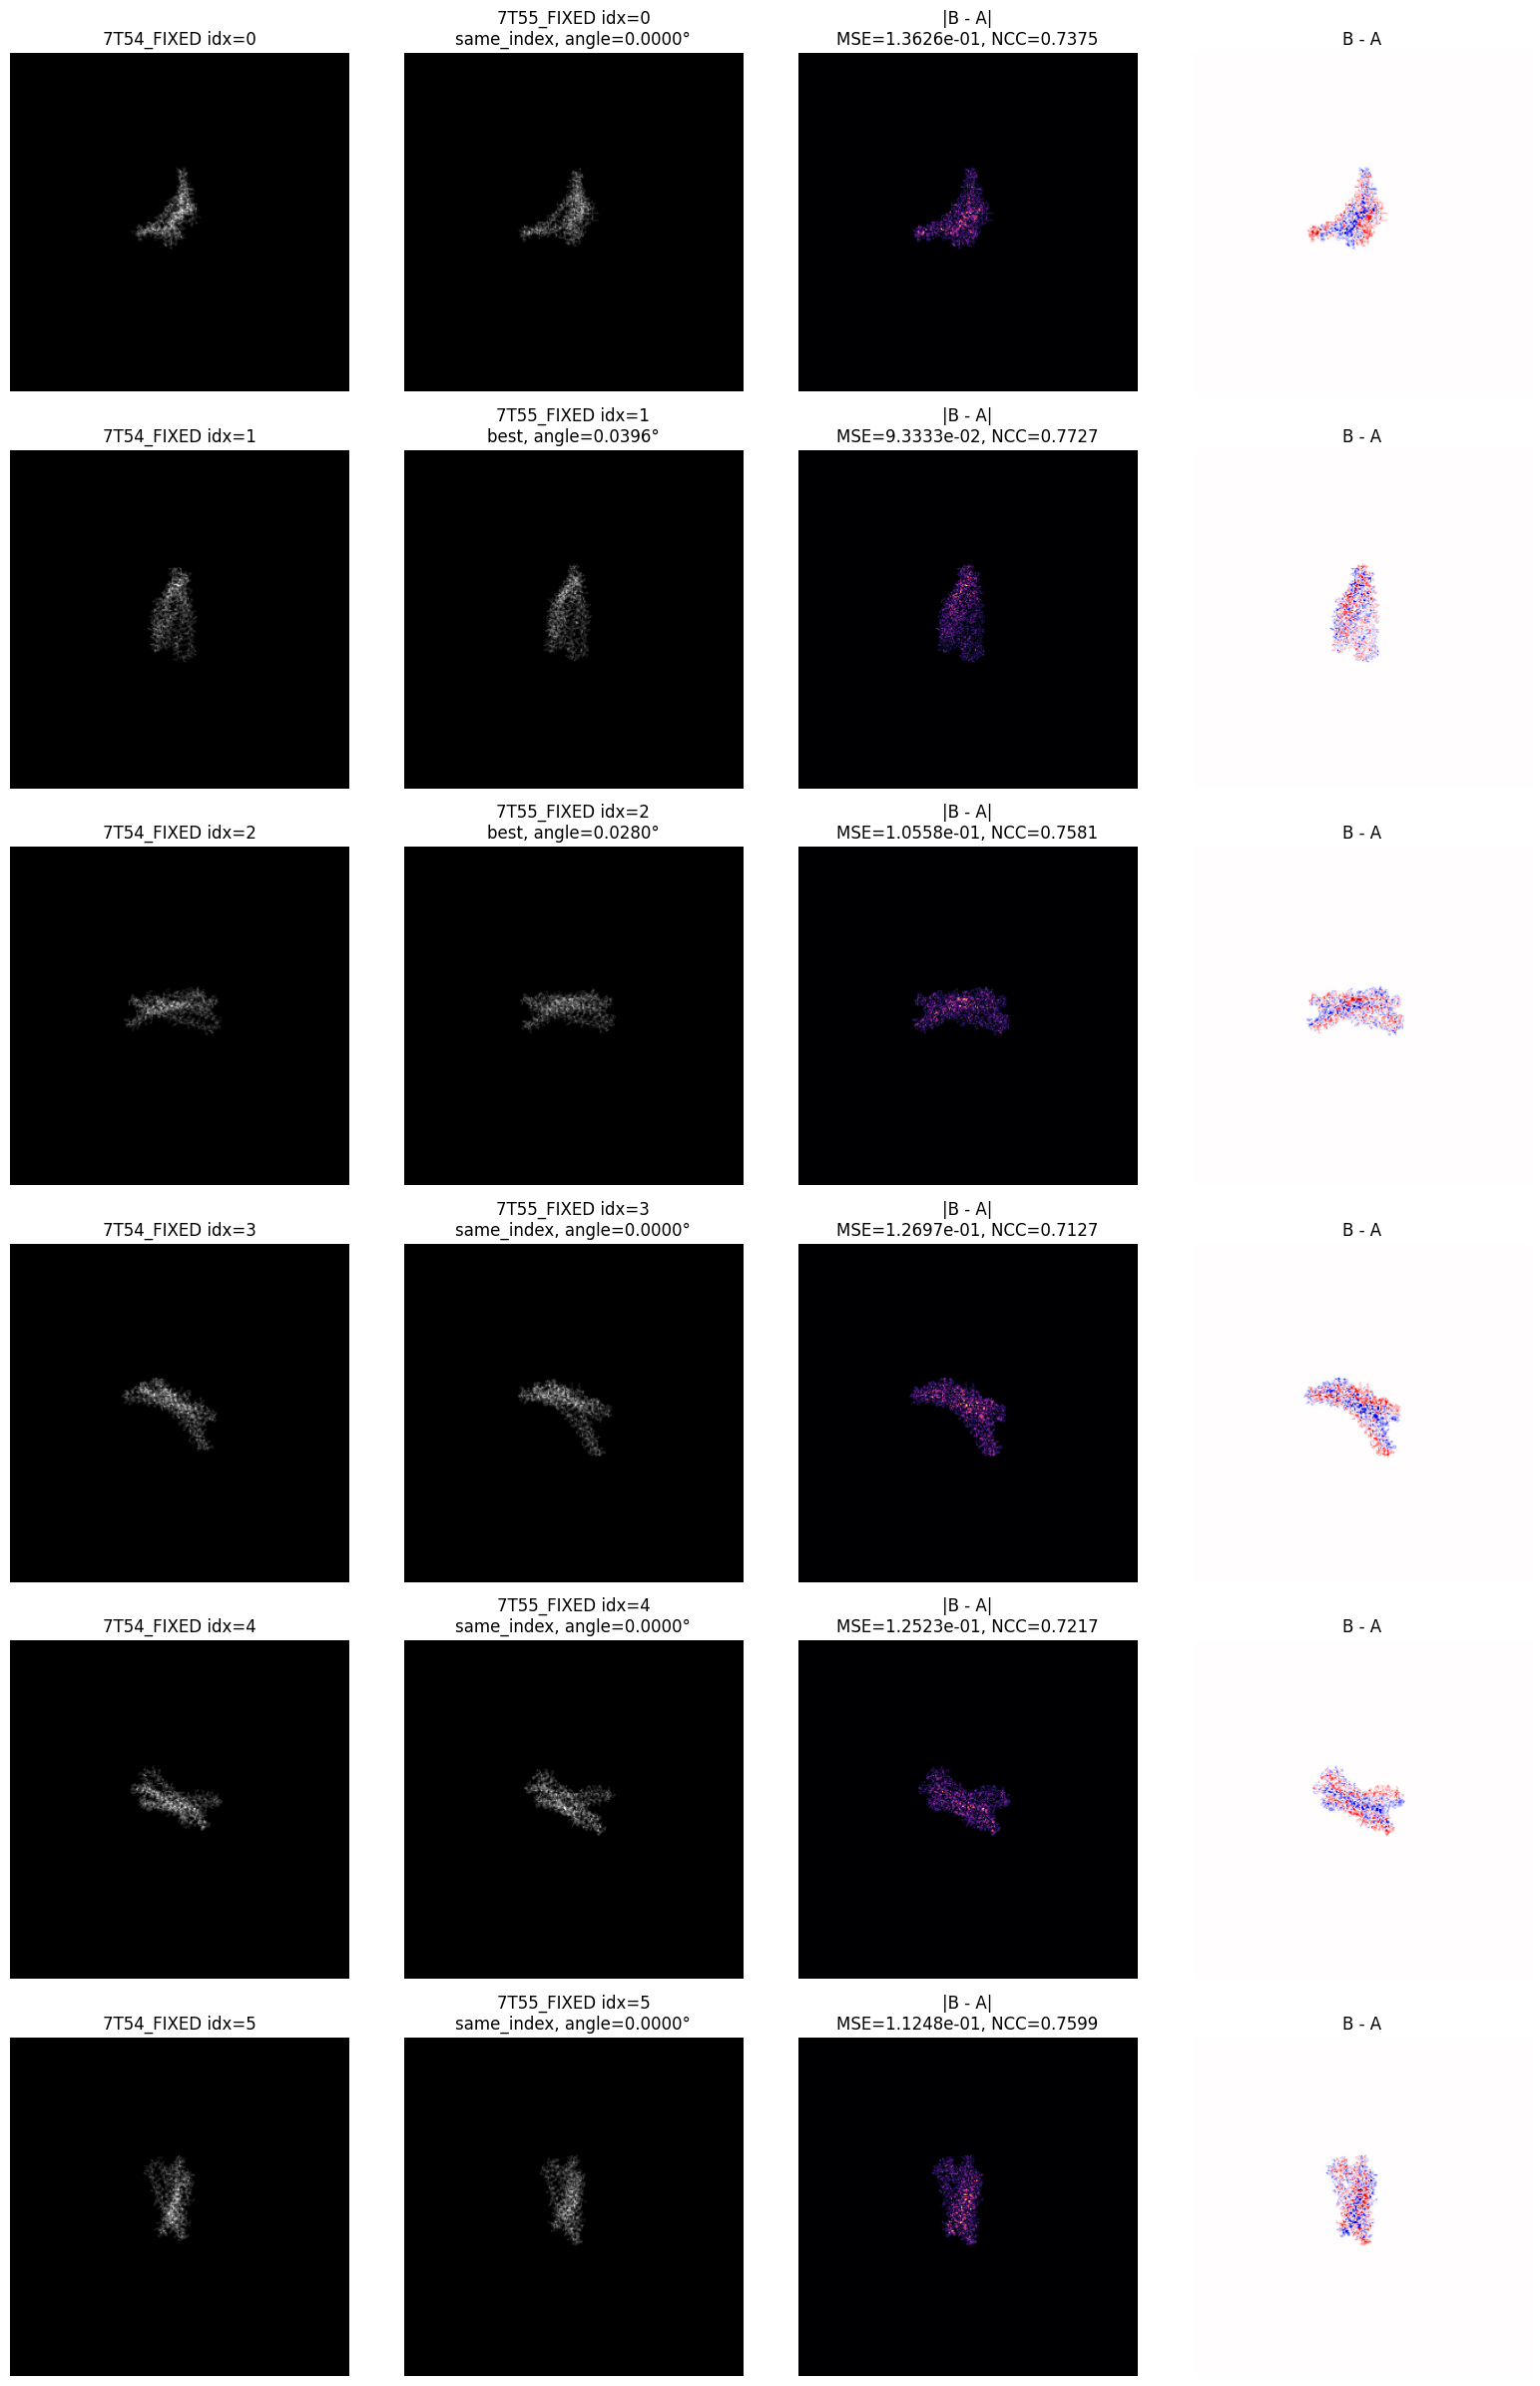

Dataset A: ../../../../pipeline_inputs/projections/7T54/7T54_FIXED_esp_projections_200.pt
Dataset B: ../../../../pipeline_inputs/projections/7T55/7T55_FIXED_esp_projections_200.pt
A[0] -> B[0] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=1.362648e-01, NCC=0.737532
A[1] -> B[1] (best), angle=0.039565°, same-index angle=0.039565°, best angle=0.039565°, MSE=9.333295e-02, NCC=0.772653
A[2] -> B[2] (best), angle=0.027976°, same-index angle=0.027976°, best angle=0.027976°, MSE=1.055835e-01, NCC=0.758137
A[3] -> B[3] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=1.269709e-01, NCC=0.712686
A[4] -> B[4] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=1.252266e-01, NCC=0.721721
A[5] -> B[5] (same_index), angle=0.000000°, same-index angle=0.000000°, best angle=0.000000°, MSE=1.124838e-01, NCC=0.759948


In [7]:
# Compare two datasets at the same rotation index when possible, otherwise use the nearest rotation.
compare_pt_path_a = pt_path
compare_data_dir_b = Path("../../../../pipeline_inputs/projections/7T55")
compare_pt_path_b = None  # Path("/path/to/7T55_esp_projections_200.pt")
compare_indices_a = None  # e.g. [0, 10, 42]
num_examples = 6
match_mode = "same_index_if_close_else_best"  # "same_index", "best"
same_index_angle_tol_deg = 1e-3

def _resolve_pt_path(default_dir, explicit_path=None):
    if explicit_path is not None:
        return Path(explicit_path)
    default_dir = Path(default_dir)
    pt_files = sorted(default_dir.glob("*.pt"))
    if not pt_files:
        raise FileNotFoundError(f"No .pt files found in {default_dir.resolve()}")
    return pt_files[0]

def _load_projection_dataset(path):
    path = Path(path)
    data = torch.load(path, map_location="cpu", weights_only=False)
    return path, data["projections"], data["rotations"], data.get("meta")

def _pairwise_rotation_angle_deg(rot_a, rot_b):
    rel = rot_a[:, None] @ rot_b[None, :, :, :].transpose(-1, -2)
    trace = rel[..., 0, 0] + rel[..., 1, 1] + rel[..., 2, 2]
    cos_theta = ((trace - 1.0) / 2.0).clamp(-1.0, 1.0)
    return torch.rad2deg(torch.arccos(cos_theta))

def _ncc(img_a, img_b, eps=1e-8):
    a = img_a - img_a.mean()
    b = img_b - img_b.mean()
    denom = a.square().mean().sqrt() * b.square().mean().sqrt() + eps
    return (a * b).mean() / denom

path_a, proj_a, rot_a, meta_a = _load_projection_dataset(compare_pt_path_a)
path_b, proj_b, rot_b, meta_b = _load_projection_dataset(_resolve_pt_path(compare_data_dir_b, compare_pt_path_b))

name_a = meta_a.get("pdb_id", path_a.stem) if isinstance(meta_a, dict) else path_a.stem
name_b = meta_b.get("pdb_id", path_b.stem) if isinstance(meta_b, dict) else path_b.stem
angle_deg = _pairwise_rotation_angle_deg(rot_a.float(), rot_b.float())

if compare_indices_a is None:
    compare_indices_a = list(range(min(num_examples, proj_a.shape[0])))

rows = len(compare_indices_a)
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), squeeze=False)
summary_rows = []

for row, idx_a in enumerate(compare_indices_a):
    if idx_a >= proj_a.shape[0]:
        raise IndexError(f"idx_a={idx_a} is out of bounds for dataset A with {proj_a.shape[0]} projections")

    same_index_available = idx_a < proj_b.shape[0]
    same_index_angle = float(angle_deg[idx_a, idx_a].item()) if same_index_available else float("inf")
    best_idx_b = int(angle_deg[idx_a].argmin().item())
    best_angle = float(angle_deg[idx_a, best_idx_b].item())

    if match_mode == "same_index":
        if not same_index_available:
            raise IndexError(f"idx_a={idx_a} has no same-index match in dataset B")
        idx_b = idx_a
        match_label = "same_index"
        match_angle = same_index_angle
    elif match_mode == "same_index_if_close_else_best" and same_index_available and same_index_angle <= same_index_angle_tol_deg:
        idx_b = idx_a
        match_label = "same_index"
        match_angle = same_index_angle
    else:
        idx_b = best_idx_b
        match_label = "best"
        match_angle = best_angle

    img_a = proj_a[idx_a].float()
    img_b = proj_b[idx_b].float()
    diff = img_b - img_a
    pair_min = float(torch.minimum(img_a.min(), img_b.min()).item())
    pair_max = float(torch.maximum(img_a.max(), img_b.max()).item())
    diff_scale = max(float(diff.abs().max().item()), 1e-8)
    mse = float(diff.square().mean().item())
    corr = float(_ncc(img_a, img_b).item())

    summary_rows.append({
        "idx_a": idx_a,
        "idx_b": idx_b,
        "match": match_label,
        "angle_deg": match_angle,
        "same_index_angle_deg": same_index_angle,
        "best_angle_deg": best_angle,
        "mse": mse,
        "ncc": corr,
    })

    axes[row, 0].imshow(img_a.numpy(), cmap="gray", origin="lower", vmin=pair_min, vmax=pair_max)
    axes[row, 0].set_title(f"{name_a} idx={idx_a}")
    axes[row, 1].imshow(img_b.numpy(), cmap="gray", origin="lower", vmin=pair_min, vmax=pair_max)
    axes[row, 1].set_title(f"{name_b} idx={idx_b}\n{match_label}, angle={match_angle:.4f}°")
    axes[row, 2].imshow(diff.abs().numpy(), cmap="magma", origin="lower")
    axes[row, 2].set_title(f"|B - A|\nMSE={mse:.4e}, NCC={corr:.4f}")
    axes[row, 3].imshow(diff.numpy(), cmap="seismic", origin="lower", vmin=-diff_scale, vmax=diff_scale)
    axes[row, 3].set_title("B - A")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Dataset A: {path_a}")
print(f"Dataset B: {path_b}")
for item in summary_rows:
    print(
        f"A[{item['idx_a']}] -> B[{item['idx_b']}] "
        f"({item['match']}), angle={item['angle_deg']:.6f}°, "
        f"same-index angle={item['same_index_angle_deg']:.6f}°, "
        f"best angle={item['best_angle_deg']:.6f}°, "
        f"MSE={item['mse']:.6e}, NCC={item['ncc']:.6f}"
    )
